In [1]:
!pip3 install pyspark

In [3]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

In [4]:
file_path = "/content/Airline_Delay_Cause.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Show the first 6 rows
print("Showing first 6 rows:")
df.show(5)

# Print schema of the DataFrame
print("Schema of DataFrame:")
df.printSchema(1)

Showing first 6 rows:
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        

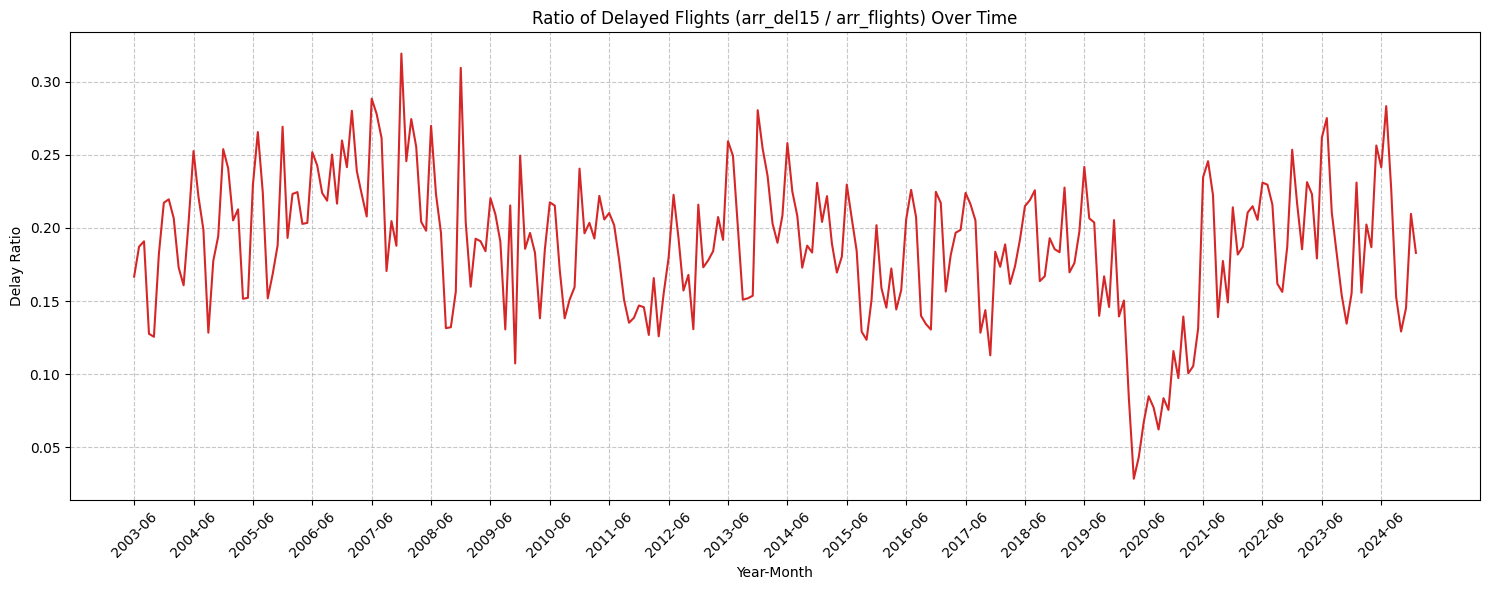

In [7]:
import matplotlib.pyplot as plt
import pyspark.sql.functions as F

# Aggregate total delayed flights and total flights by year and month
ratio_df = df.groupBy("year", "month") \
    .agg(
        F.sum("arr_del15").alias("total_delays"),
        F.sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_ratio", F.col("total_delays") / F.col("total_flights")) \
    .orderBy("year", "month")

# Convert to Pandas for plotting
pandas_ratio = ratio_df.toPandas()

# Create a 'Date' string column for the x-axis
pandas_ratio['date'] = pandas_ratio['year'].astype(str) + '-' + pandas_ratio['month'].astype(str).str.zfill(2)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(pandas_ratio['date'], pandas_ratio['delay_ratio'], color='tab:red', linewidth=1.5)
plt.title('Ratio of Delayed Flights (arr_del15 / arr_flights) Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Delay Ratio')
plt.xticks(pandas_ratio['date'][::12], rotation=45) # Show label every 12 months for clarity
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

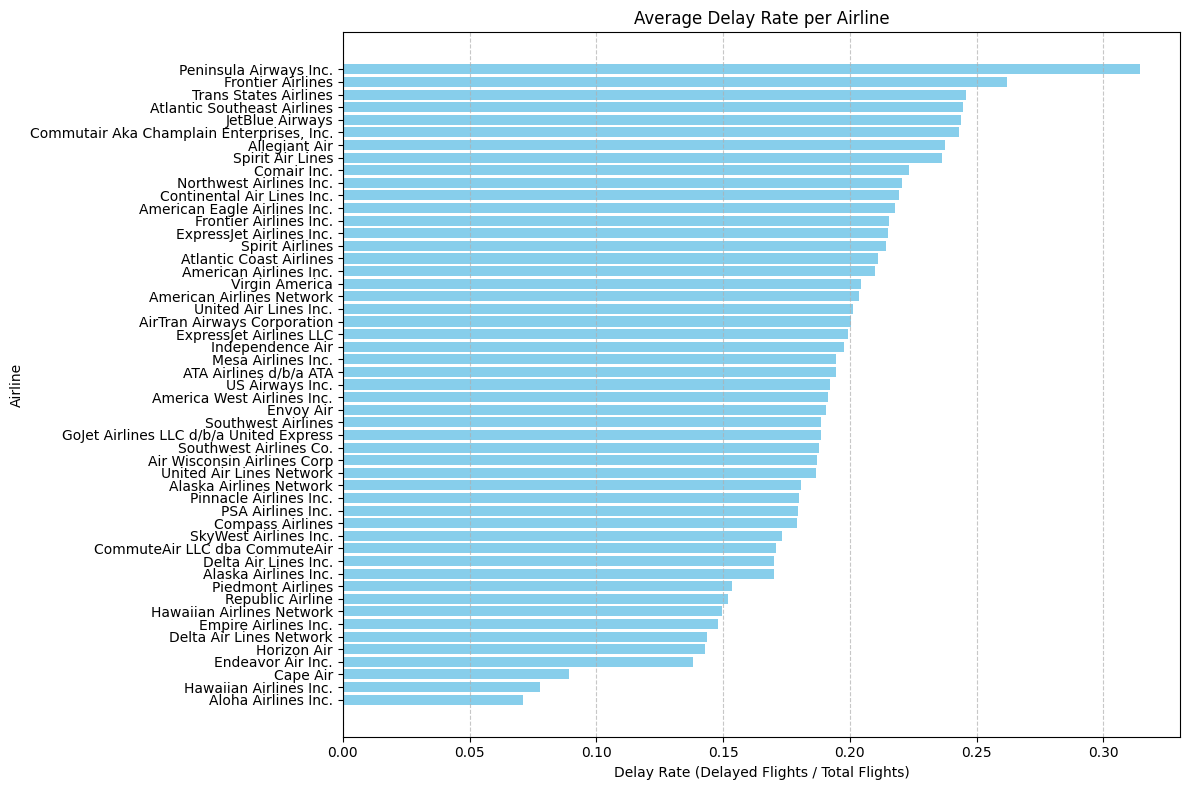

In [8]:
# Calculate delay rate per carrier
carrier_delay_df = df.groupBy("carrier_name") \
    .agg(
        F.sum("arr_del15").alias("total_delays"),
        F.sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_rate", F.col("total_delays") / F.col("total_flights")) \
    .orderBy(F.desc("delay_rate"))

# Convert to Pandas for plotting
pandas_carrier_delays = carrier_delay_df.toPandas()

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(pandas_carrier_delays["carrier_name"], pandas_carrier_delays["delay_rate"], color='skyblue')
plt.gca().invert_yaxis()  # Highest rates at the top
plt.title('Average Delay Rate per Airline')
plt.xlabel('Delay Rate (Delayed Flights / Total Flights)')

plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

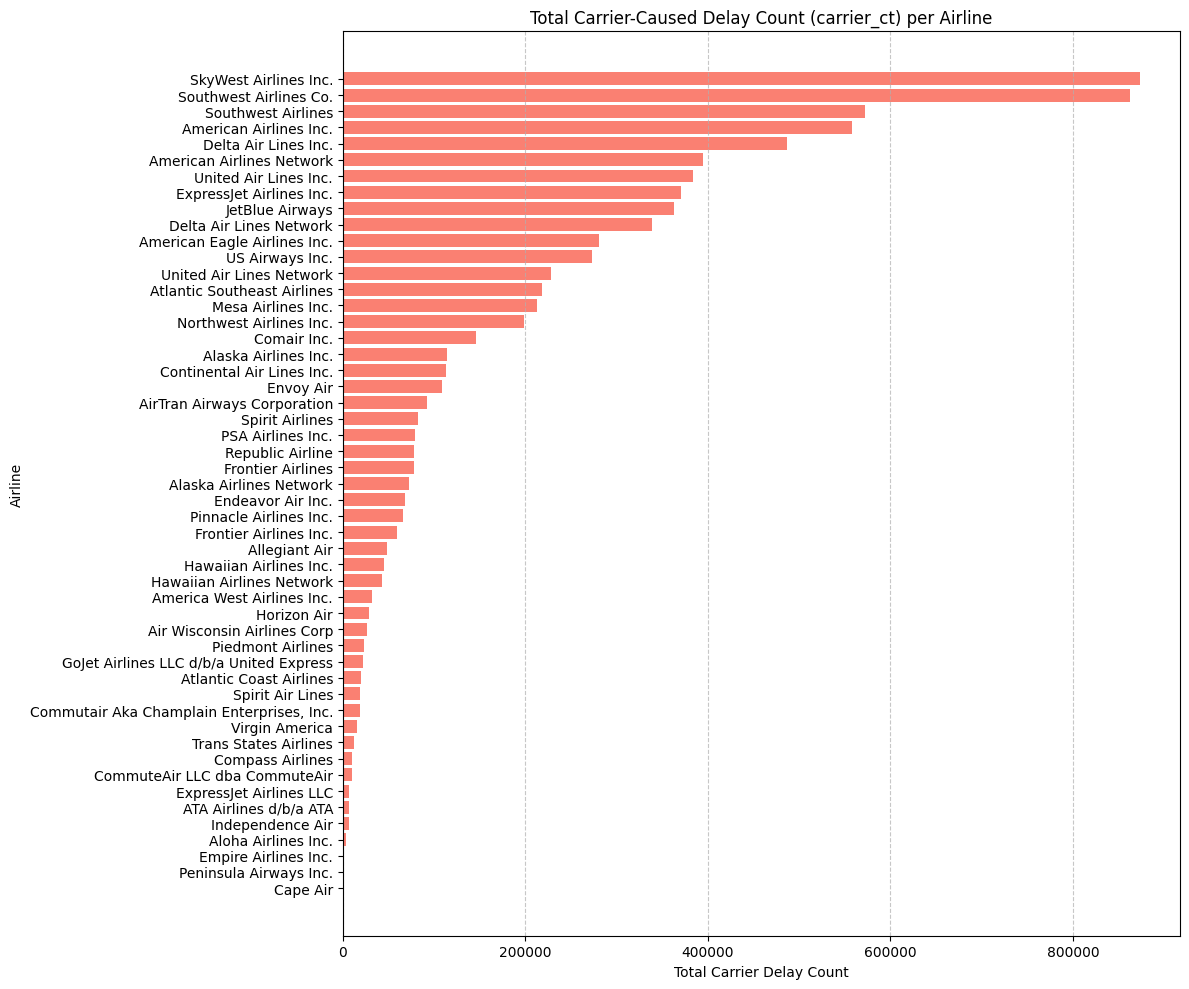

In [9]:
carrier_ct_df = df.groupBy("carrier_name") \
    .agg(F.sum("carrier_ct").alias("total_carrier_ct")) \
    .orderBy(F.desc("total_carrier_ct"))

# Convert
pandas_carrier_ct = carrier_ct_df.toPandas()

# Plotting
plt.figure(figsize=(12, 10))
plt.barh(pandas_carrier_ct["carrier_name"], pandas_carrier_ct["total_carrier_ct"], color='salmon')
plt.gca().invert_yaxis()
plt.title('Total Carrier-Caused Delay Count (carrier_ct) per Airline')
plt.xlabel('Total Carrier Delay Count')
plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

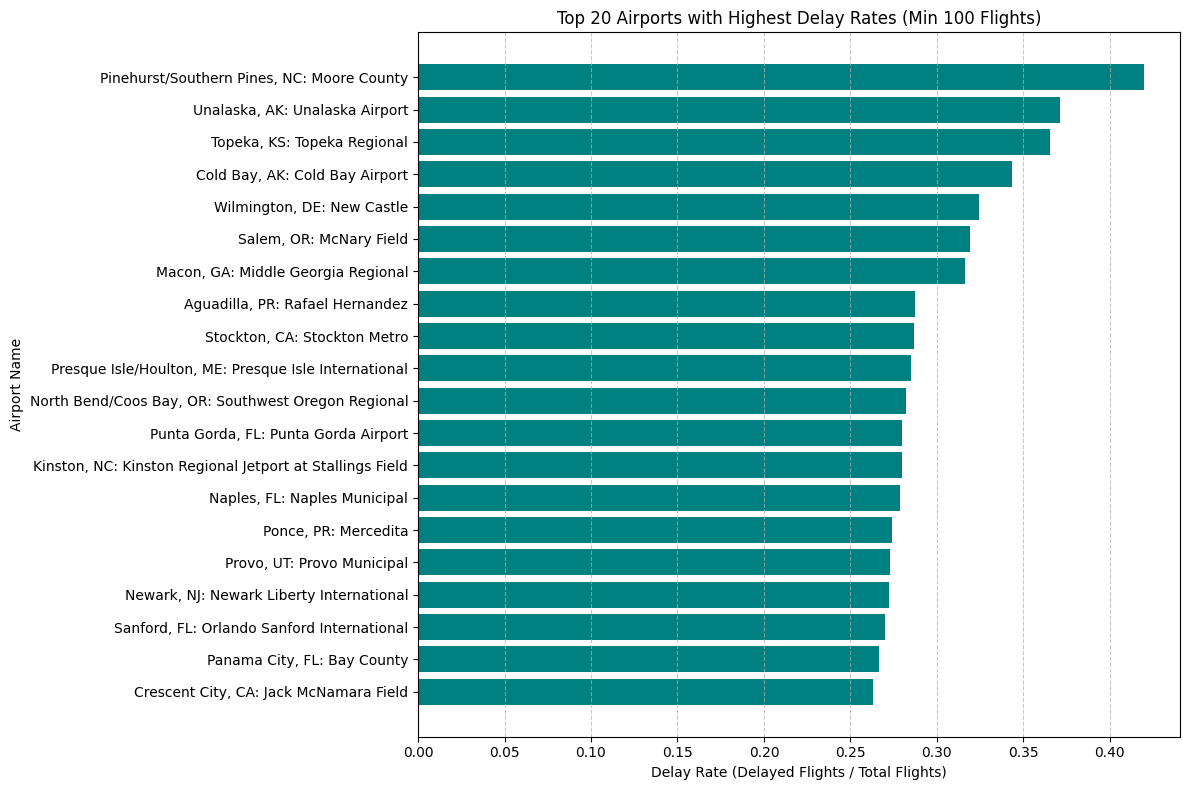

In [10]:
airport_delay_df = df.groupBy("airport", "airport_name") \
    .agg(
        F.sum("arr_del15").alias("total_delays"),
        F.sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_rate", F.col("total_delays") / F.col("total_flights")) \
    .filter("total_flights > 100")  # Filter out airports with very low traffic for more reliable rates

# Get top 20 airports for visualization
top_20_airports = airport_delay_df.orderBy(F.desc("delay_rate")).limit(20).toPandas()

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(top_20_airports["airport_name"], top_20_airports["delay_rate"], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 20 Airports with Highest Delay Rates (Min 100 Flights)')
plt.xlabel('Delay Rate (Delayed Flights / Total Flights)')
plt.ylabel('Airport Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

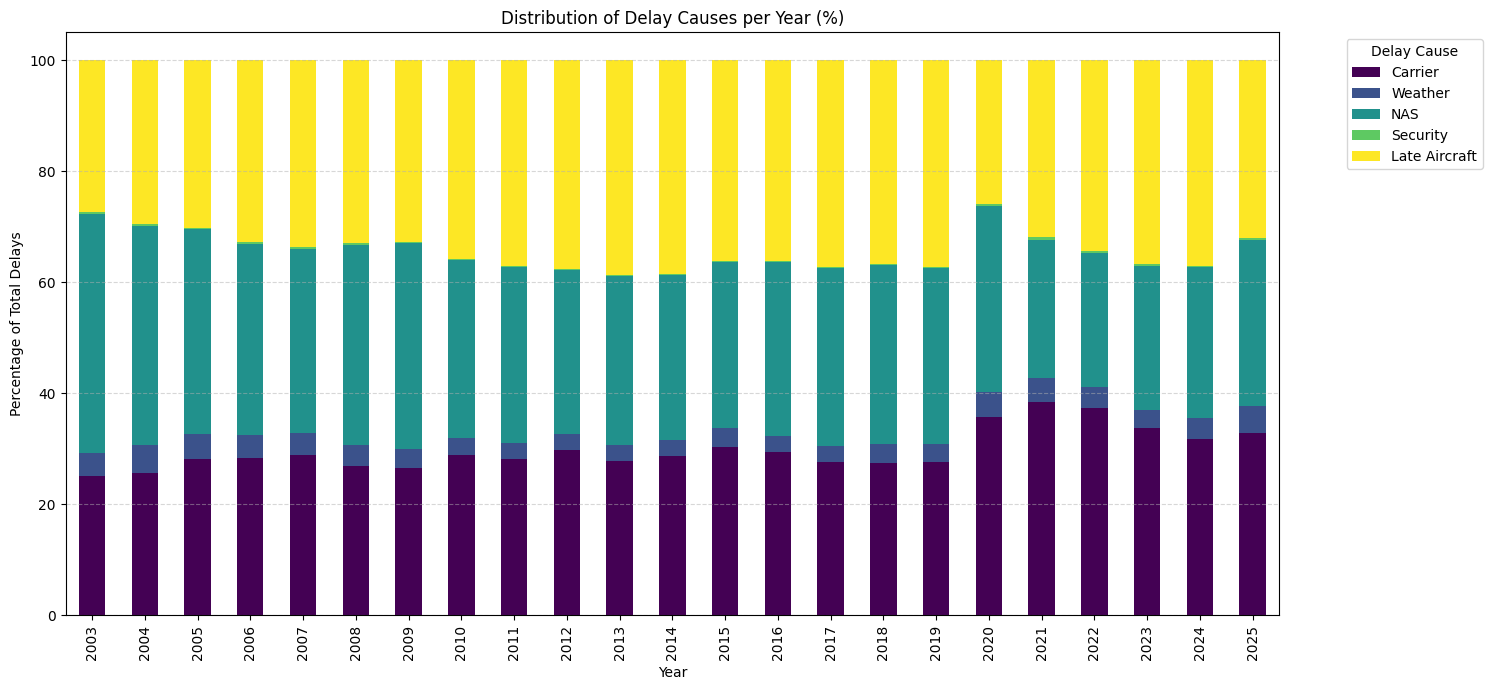

In [11]:
causes_df = df.groupBy("year") \
    .agg(
        F.sum("carrier_ct").alias("Carrier"),
        F.sum("weather_ct").alias("Weather"),
        F.sum("nas_ct").alias("NAS"),
        F.sum("security_ct").alias("Security"),
        F.sum("late_aircraft_ct").alias("Late Aircraft")
    ) \
    .orderBy("year")

# Convert to Pandas for transformation and plotting
pandas_causes = causes_df.toPandas().set_index("year")

# Calculate percentages for each year (row-wise)
pandas_causes_pct = pandas_causes.div(pandas_causes.sum(axis=1), axis=0) * 100

# Plotting a stacked bar chart
pandas_causes_pct.plot(kind='bar', stacked=True, figsize=(15, 7), colormap='viridis')

plt.title('Distribution of Delay Causes per Year (%)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Delays')
plt.legend(title="Delay Cause", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

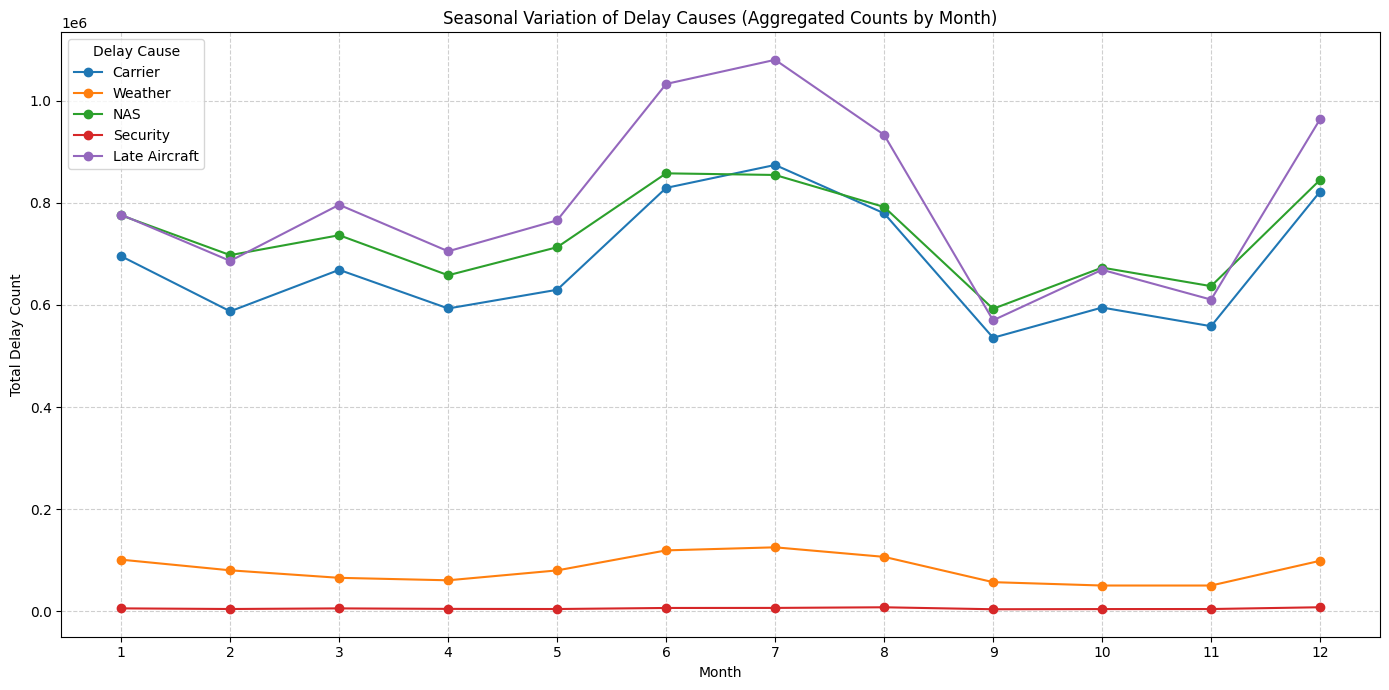

In [12]:
seasonal_causes_df = df.groupBy("month") \
    .agg(
        F.sum("carrier_ct").alias("Carrier"),
        F.sum("weather_ct").alias("Weather"),
        F.sum("nas_ct").alias("NAS"),
        F.sum("security_ct").alias("Security"),
        F.sum("late_aircraft_ct").alias("Late Aircraft")
    ) \
    .orderBy("month")


pandas_seasonal = seasonal_causes_df.toPandas().set_index("month")
plt.figure(figsize=(14, 7))
for column in pandas_seasonal.columns:
    plt.plot(pandas_seasonal.index, pandas_seasonal[column], marker='o', label=column)

plt.title('Seasonal Variation of Delay Causes (Aggregated Counts by Month)')
plt.xlabel('Month')
plt.ylabel('Total Delay Count')
plt.xticks(range(1, 13))
plt.legend(title="Delay Cause")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_528/1571528488.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='delay_percentage', data=pandas_monthly_stats, palette='coolwarm')


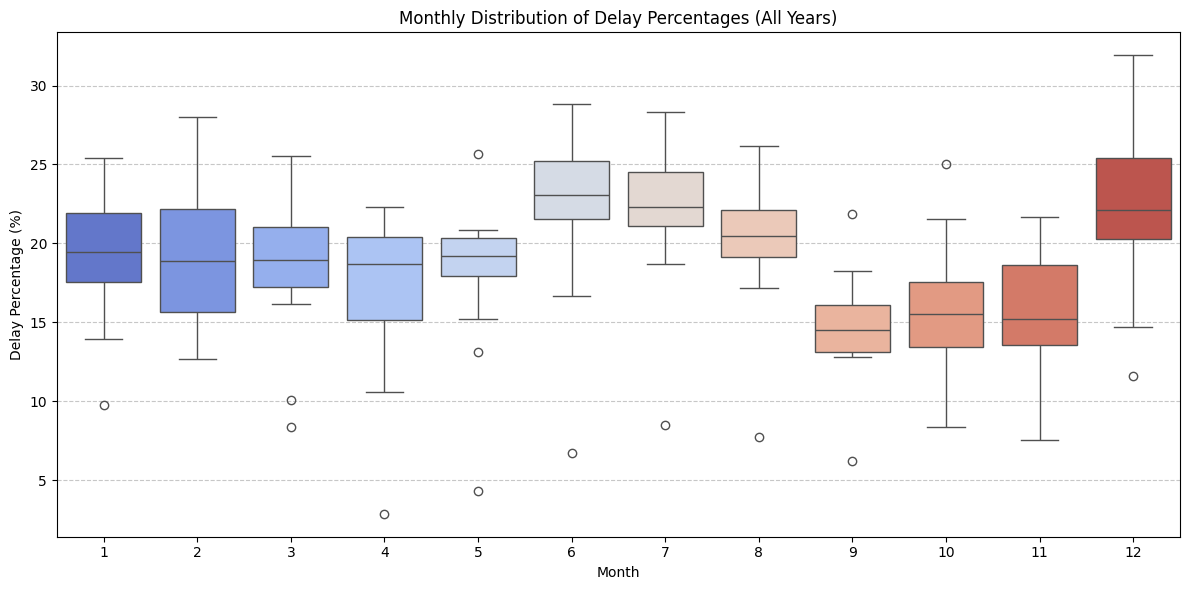

In [13]:
import seaborn as sns
monthly_stats = df.groupBy("year", "month") \
    .agg(
        F.sum("arr_del15").alias("total_delays"),
        F.sum("arr_flights").alias("total_flights")
    ) \
    .withColumn("delay_percentage", (F.col("total_delays") / F.col("total_flights")) * 100) \
    .orderBy("month")

pandas_monthly_stats = monthly_stats.toPandas()

plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='delay_percentage', data=pandas_monthly_stats, palette='coolwarm')

plt.title('Monthly Distribution of Delay Percentages (All Years)')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()